# 05 — Root Cause Prioritization

## Objective

Combine downtime and reliability findings to prioritize the main remaining production losses after LSS.

Prioritization is based on:

- current downtime impact
- change from before to after LSS
- event frequency
- average event duration

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
downtime_before = pd.read_csv(RAW_DIR / "DowntimeDataset.csv")
downtime_after = pd.read_csv(RAW_DIR / "DowntimeDataset_afterLSS.csv")

oee_before = pd.read_csv(RAW_DIR / "OEEdataset.csv")
oee_after = pd.read_csv(RAW_DIR / "OEEdataset_afterLSS.csv")

for df in [downtime_before, downtime_after, oee_before, oee_after]:
    df.dropna(axis=1, how="all", inplace=True)
    df.dropna(axis=0, how="all", inplace=True)

C:\Users\erenk\AppData\Local\Temp\ipykernel_27884\3423606821.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  downtime_after = pd.read_csv(RAW_DIR / "DowntimeDataset_afterLSS.csv")


In [3]:
downtime_before = downtime_before.rename(columns={
    "StopGroup": "stop_group",
    "Stop": "stop",
    "StopType": "stop_type",
    "StopDuration(min)": "duration_min"
})

downtime_after = downtime_after.rename(columns={
    "Stop group": "stop_group",
    "Stop": "stop",
    "Stop type": "stop_type",
    "Stop duration (min) (TTR)": "duration_min"
})

downtime_before["period"] = "Before LSS"
downtime_after["period"] = "After LSS"

downtime = pd.concat(
    [downtime_before, downtime_after],
    ignore_index=True
)

In [4]:
unplanned = downtime[
    downtime["stop_type"].str.contains(
        "Unplanned",
        case=False,
        na=False
    )
].copy()

production_days = {
    "Before LSS": len(oee_before),
    "After LSS": len(oee_after)
}

production_days

{'Before LSS': 62, 'After LSS': 43}

In [5]:
stop_priority = (
    unplanned.groupby(["period", "stop_group", "stop"])
    .agg(
        events=("duration_min", "size"),
        total_downtime_min=("duration_min", "sum"),
        avg_duration_min=("duration_min", "mean")
    )
    .reset_index()
)

stop_priority["production_days"] = (
    stop_priority["period"].map(production_days)
)

stop_priority["downtime_min_per_day"] = (
    stop_priority["total_downtime_min"]
    / stop_priority["production_days"]
)

stop_priority["events_per_day"] = (
    stop_priority["events"]
    / stop_priority["production_days"]
)

stop_priority.head()

,period,stop_group,stop,events,total_downtime_min,avg_duration_min,production_days,downtime_min_per_day,events_per_day
0,After LSS,FAILURE,AUTOMATION FAILURE,23,429.0,18.652174,43,9.976744,0.534884
1,After LSS,FAILURE,MECHANICAL FAILURE,35,818.0,23.371429,43,19.023256,0.813953
2,After LSS,FAILURE,OTHER FAILURE,35,334.0,9.542857,43,7.767442,0.813953
3,After LSS,FAILURE,WIRE FAILURE,23,109.0,4.739130,43,2.534884,0.534884
4,After LSS,MATERIALS,CRACKED WIP BRICKS,5,40.0,8.000000,43,0.930233,0.116279


In [6]:
priority_table = stop_priority.pivot_table(
    index=["stop_group", "stop"],
    columns="period",
    values=[
        "downtime_min_per_day",
        "events_per_day",
        "avg_duration_min"
    ],
    fill_value=0
)

priority_table.columns = [
    f"{metric}_{period.replace(' ', '_').lower()}"
    for metric, period in priority_table.columns
]

priority_table = priority_table.reset_index()

priority_table["downtime_change_min_per_day"] = (
    priority_table["downtime_min_per_day_after_lss"]
    - priority_table["downtime_min_per_day_before_lss"]
)

priority_table["event_frequency_change"] = (
    priority_table["events_per_day_after_lss"]
    - priority_table["events_per_day_before_lss"]
)

priority_table = priority_table.sort_values(
    "downtime_min_per_day_after_lss",
    ascending=False
)

priority_table

,stop_group,stop,avg_duration_min_after_lss,avg_duration_min_before_lss,downtime_min_per_day_after_lss,downtime_min_per_day_before_lss,events_per_day_after_lss,events_per_day_before_lss,downtime_change_min_per_day,event_frequency_change
1,FAILURE,MECHANICAL FAILURE,23.371429,16.303371,19.023256,23.403226,0.813953,1.435484,-4.379970,-0.621530
8,MATERIALS,MANUAL BRICK HANDLING,9.575000,13.111194,17.813953,28.337097,1.860465,2.161290,-10.523143,-0.300825
11,MATERIALS,RACK STARVATION,7.427184,10.033333,17.790698,1.456452,2.395349,0.145161,16.334246,2.250188
0,FAILURE,AUTOMATION FAILURE,18.652174,13.460305,9.976744,28.440323,0.534884,2.112903,-18.463578,-1.578020
2,FAILURE,OTHER FAILURE,9.542857,9.650000,7.767442,0.311290,0.813953,0.032258,7.456152,0.781695
12,MATERIALS,RACKS,7.818182,10.427273,6.000000,3.700000,0.767442,0.354839,2.300000,0.412603
7,MATERIALS,KILN CAR STARVATION,11.083333,16.055556,3.093023,2.330645,0.279070,0.145161,0.762378,0.133908
3,FAILURE,WIRE FAILURE,4.739130,0.000000,2.534884,0.000000,0.534884,0.000000,2.534884,0.534884
18,OPERATIONAL,OTHER,11.333333,15.962500,2.372093,2.059677,0.209302,0.129032,0.312416,0.080270
6,MATERIALS,EXTRUSION DEFECTS,7.000000,0.000000,1.953488,0.000000,0.279070,0.000000,1.953488,0.279070


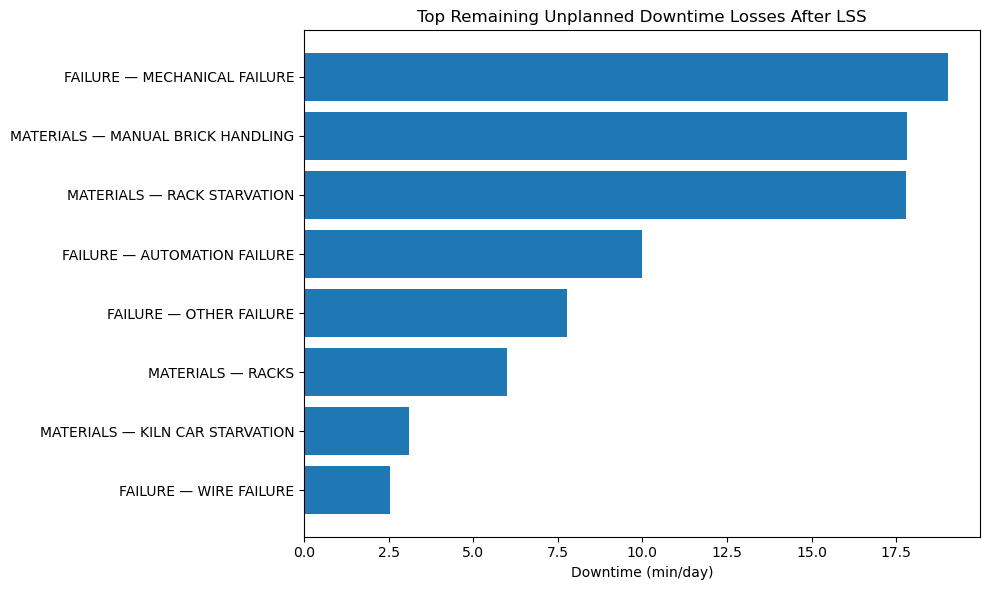

In [7]:
top_losses = (
    priority_table
    .sort_values(
        "downtime_min_per_day_after_lss",
        ascending=False
    )
    .head(8)
    .copy()
)

top_losses["label"] = (
    top_losses["stop_group"]
    + " — "
    + top_losses["stop"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_losses["label"][::-1],
    top_losses["downtime_min_per_day_after_lss"][::-1]
)

plt.xlabel("Downtime (min/day)")
plt.ylabel("")
plt.title("Top Remaining Unplanned Downtime Losses After LSS")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_remaining_downtime_losses_after_lss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
priority_view = priority_table[
    [
        "stop_group",
        "stop",
        "downtime_min_per_day_after_lss",
        "downtime_change_min_per_day",
        "events_per_day_after_lss",
        "avg_duration_min_after_lss"
    ]
].head(8)

priority_view.round(2)

,stop_group,stop,downtime_min_per_day_after_lss,downtime_change_min_per_day,events_per_day_after_lss,avg_duration_min_after_lss
1,FAILURE,MECHANICAL FAILURE,19.02,-4.38,0.81,23.37
8,MATERIALS,MANUAL BRICK HANDLING,17.81,-10.52,1.86,9.57
11,MATERIALS,RACK STARVATION,17.79,16.33,2.40,7.43
0,FAILURE,AUTOMATION FAILURE,9.98,-18.46,0.53,18.65
2,FAILURE,OTHER FAILURE,7.77,7.46,0.81,9.54
12,MATERIALS,RACKS,6.00,2.30,0.77,7.82
7,MATERIALS,KILN CAR STARVATION,3.09,0.76,0.28,11.08
3,FAILURE,WIRE FAILURE,2.53,2.53,0.53,4.74


### Improvement Priorities

The post-LSS loss profile shows that the main remaining opportunities are concentrated in a small number of causes.

- **Rack Starvation** emerged as the strongest new loss, increasing from 1.5 to 17.8 min/day.
- **Other Failure** increased from 0.3 to 7.8 min/day and became a relevant new failure category.
- **Mechanical Failure** remains the largest current failure-related loss at 19.0 min/day, despite improving from 23.4 min/day.
- **Manual Brick Handling** remains a major material-flow loss at 17.8 min/day, although it improved substantially from 28.3 min/day.
- **Automation Failure** improved strongly, falling from 28.4 to 10.0 min/day.

The next improvement cycle should therefore focus primarily on emerging material-flow constraints and remaining equipment failure losses.

In [9]:
final_priorities = priority_view[
    priority_view["stop"].isin([
        "RACK STARVATION",
        "MECHANICAL FAILURE",
        "MANUAL BRICK HANDLING",
        "OTHER FAILURE"
    ])
].copy()

final_priorities = final_priorities.sort_values(
    "downtime_min_per_day_after_lss",
    ascending=False
)

final_priorities.round(2)

,stop_group,stop,downtime_min_per_day_after_lss,downtime_change_min_per_day,events_per_day_after_lss,avg_duration_min_after_lss
1,FAILURE,MECHANICAL FAILURE,19.02,-4.38,0.81,23.37
8,MATERIALS,MANUAL BRICK HANDLING,17.81,-10.52,1.86,9.57
11,MATERIALS,RACK STARVATION,17.79,16.33,2.40,7.43
2,FAILURE,OTHER FAILURE,7.77,7.46,0.81,9.54


## Final Improvement Priorities

The post-LSS analysis identifies four main improvement priorities:

1. **Mechanical Failure** — remains the largest current equipment-related loss at 19.0 min/day, despite improving from the pre-LSS period.

2. **Manual Brick Handling** — remains a major material-flow loss at 17.8 min/day, although downtime decreased substantially after LSS.

3. **Rack Starvation** — increased sharply from 1.5 to 17.8 min/day and represents the most significant emerging production constraint.

4. **Other Failure** — increased from 0.3 to 7.8 min/day and should be investigated further to identify the underlying failure modes.

Automation Failure improved substantially and is therefore no longer the dominant improvement priority.